# Blood-Brain Barrier Penetration — Zero-shot XGBoost

Binary classification on the [BBB_Martins](https://tdcommons.ai/single_pred_tasks/adme/#bbb-blood-brain-barrier-martins-et-al) dataset.

**Task:** predict whether a molecule crosses the blood-brain barrier (1 = penetrates, 0 = does not).  
**Features:** 1 024-bit Morgan fingerprints (ECFP4) computed with RDKit.  
**Model:** `ZeroShotXGBClassifier` — no hyperparameter tuning, parameters chosen automatically from dataset statistics.

## 1. Dependencies

In [ ]:
# Uncomment to install if needed
# !pip install rdkit zsxgboost

## 2. Load dataset

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/bbb_martins.tab", sep="\t")

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["Y"], random_state=42)
train_df, valid_df = train_test_split(train_df, test_size=0.125, stratify=train_df["Y"], random_state=42)
# 0.125 × 0.8 = 0.10 of total → ~70 / 10 / 20 split

print(f"Train: {len(train_df):,}  Valid: {len(valid_df):,}  Test: {len(test_df):,}")
print(f"Class distribution (train): {train_df['Y'].value_counts().to_dict()}")

## 3. Compute Morgan fingerprints

In [3]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem


def smiles_to_ecfp4(smiles_list, n_bits=1024):
    """Convert a list of SMILES to a binary ECFP4 fingerprint matrix."""
    fps = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            fps.append(np.zeros(n_bits, dtype=np.uint8))
        else:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=n_bits)
            fps.append(np.frombuffer(fp.ToBitString().encode(), dtype="u1") - ord("0"))
    return np.vstack(fps).astype(np.uint8)


X_train = smiles_to_ecfp4(train_df["Drug"])
X_valid = smiles_to_ecfp4(valid_df["Drug"])
X_test  = smiles_to_ecfp4(test_df["Drug"])

y_train = train_df["Y"].values.astype(int)
y_valid = valid_df["Y"].values.astype(int)
y_test  = test_df["Y"].values.astype(int)

print(f"Fingerprint matrix shape: {X_train.shape}")
print(f"Sparsity: {(X_train == 0).mean():.1%}")

Fingerprint matrix shape: (1421, 1024)
Sparsity: 95.9%


[18:21:38] WARNING: not removing hydrogen atom without neighbors
[18:21:38] WARNING: not removing hydrogen atom without neighbors
[18:21:38] WARNING: not removing hydrogen atom without neighbors
[18:21:38] WARNING: not removing hydrogen atom without neighbors
[18:21:38] WARNING: not removing hydrogen atom without neighbors
[18:21:38] WARNING: not removing hydrogen atom without neighbors
[18:21:38] WARNING: not removing hydrogen atom without neighbors
[18:21:38] WARNING: not removing hydrogen atom without neighbors
[18:21:38] WARNING: not removing hydrogen atom without neighbors
[18:21:38] WARNING: not removing hydrogen atom without neighbors
[18:21:38] WARNING: not removing hydrogen atom without neighbors
[18:21:38] WARNING: not removing hydrogen atom without neighbors
[18:21:38] WARNING: not removing hydrogen atom without neighbors
[18:21:38] WARNING: not removing hydrogen atom without neighbors
[18:21:38] WARNING: not removing hydrogen atom without neighbors
[18:21:38] WARNING: not r

## 4. Inspect the dataset profile

In [4]:
from zsxgboost.inspector import inspect

# Combine train + valid as the fitting set (test is held out for final evaluation)
import numpy as np
X_fit = np.vstack([X_train, X_valid])
y_fit = np.concatenate([y_train, y_valid])

profile = inspect(X_fit, y_fit)
print(profile)

DatasetProfile(
  n_samples=1624, n_features=1024, n_p_ratio=1.59
  sparsity=0.959, is_sparse_counts=True
  binary_feature_fraction=1.000, feature_signal_strength=0.053
  task='binary_classification'
  imbalance_ratio=0.30
)


In [5]:
from zsxgboost.params import get_params

params = get_params(profile)
print("Chosen hyperparameters:")
for k, v in params.items():
    print(f"  {k}: {v}")

Chosen hyperparameters:
  tree_method: hist
  device: cpu
  learning_rate: 0.1
  n_estimators: 1000
  early_stopping_rounds: 50
  max_depth: 3
  min_child_weight: 1
  subsample: 0.8
  colsample_bytree: 0.75
  reg_alpha: 0.5
  reg_lambda: 2.0
  gamma: 0.1
  max_bin: 64
  nthread: 10
  objective: binary:logistic
  scale_pos_weight: 0.3013
  eval_metric: auc


## 5. Train the classifier

In [6]:
from zsxgboost import ZeroShotXGBClassifier

clf = ZeroShotXGBClassifier(verbose=True)
clf.fit(X_fit, y_fit)

print(f"\nBest boosting round: {clf.best_iteration_}")

18:21:38 INFO     Binary classification | n=1624, p=1024 | imbalance_ratio=0.30 | sparse_counts=True

         DEBUG    objective=binary:logistic | eval_metric=auc | lr=0.1 | max_depth=3 | colsample_bytree=0.75

         DEBUG    Train split: 1461 rows | Val split: 163 rows

[0]	val-auc:0.77137


[1]	val-auc:0.82800


...

[112]	val-auc:0.91747


[113]	val-auc:0.91768


[114]	val-auc:0.91726


         SUCCESS  Training complete | best_iteration=65


Best boosting round: 65


## 6. Evaluate on the test set

In [7]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    classification_report,
)

y_prob = clf.predict_proba(X_test)[:, 1]
y_pred = clf.predict(X_test)

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc  = average_precision_score(y_test, y_prob)

print(f"ROC-AUC : {roc_auc:.4f}")
print(f"PR-AUC  : {pr_auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["non-BBB", "BBB"]))

ROC-AUC : 0.8636
PR-AUC  : 0.9453



              precision    recall  f1-score   support

     non-BBB       0.68      0.60      0.64       103
         BBB       0.87      0.90      0.89       303

    accuracy                           0.83       406
   macro avg       0.78      0.75      0.76       406
weighted avg       0.82      0.83      0.82       406



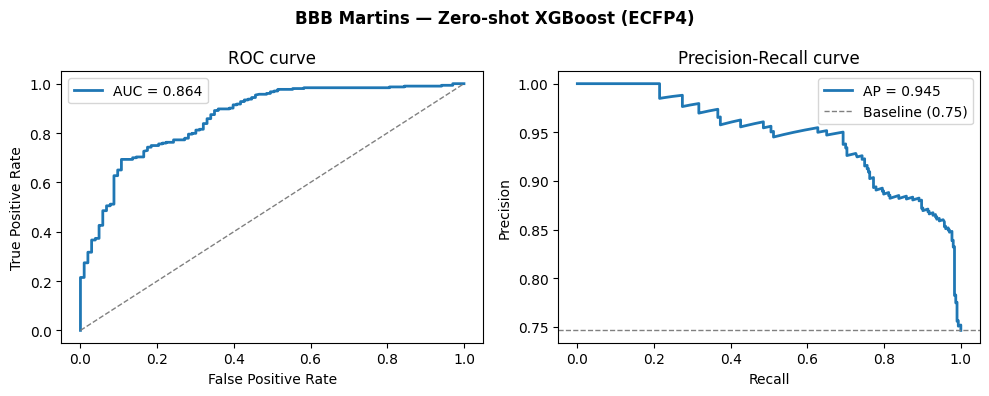

In [8]:
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)
prec, rec, _ = precision_recall_curve(y_test, y_prob)
baseline_pr = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ROC curve
axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="grey", lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve")
axes[0].legend()

# PR curve
axes[1].plot(rec, prec, lw=2, label=f"AP = {pr_auc:.3f}")
axes[1].axhline(baseline_pr, linestyle="--", color="grey", lw=1,
                label=f"Baseline ({baseline_pr:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")
axes[1].legend()

plt.suptitle("BBB Martins — Zero-shot XGBoost (ECFP4)", fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Default Random Forest baseline

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight="balanced", random_state=42)
rf.fit(X_fit, y_fit)

y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf  = rf.predict(X_test)

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
pr_auc_rf  = average_precision_score(y_test, y_prob_rf)

print(f"ROC-AUC : {roc_auc_rf:.4f}")
print(f"PR-AUC  : {pr_auc_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=["non-BBB", "BBB"]))

## 8. Default XGBoost baseline

In [ ]:
from xgboost import XGBClassifier

xgb_default = XGBClassifier(random_state=42, eval_metric="auc", verbosity=0)
xgb_default.fit(X_fit, y_fit)

y_prob_xgb0 = xgb_default.predict_proba(X_test)[:, 1]
y_pred_xgb0 = xgb_default.predict(X_test)

roc_auc_xgb0 = roc_auc_score(y_test, y_prob_xgb0)
pr_auc_xgb0  = average_precision_score(y_test, y_prob_xgb0)

print(f"ROC-AUC : {roc_auc_xgb0:.4f}")
print(f"PR-AUC  : {pr_auc_xgb0:.4f}")
print()
print(classification_report(y_test, y_pred_xgb0, target_names=["non-BBB", "BBB"]))

## 9. Logistic Regression baseline

## 10. Comparison

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Zero-shot XGBoost",
        "Default XGBoost",
        "Default Random Forest",
        "Logistic Regression",
    ],
    "ROC-AUC": [roc_auc,  roc_auc_xgb0, roc_auc_rf, roc_auc_lr],
    "PR-AUC":  [pr_auc,   pr_auc_xgb0,  pr_auc_rf,  pr_auc_lr],
})
results = results.set_index("Model")
print(results.to_string(float_format="{:.4f}".format))

In [ ]:
fpr_rf,   tpr_rf,   _ = roc_curve(y_test, y_prob_rf)
fpr_xgb0, tpr_xgb0, _ = roc_curve(y_test, y_prob_xgb0)
fpr_lr,   tpr_lr,   _ = roc_curve(y_test, y_prob_lr)

prec_rf,   rec_rf,   _ = precision_recall_curve(y_test, y_prob_rf)
prec_xgb0, rec_xgb0, _ = precision_recall_curve(y_test, y_prob_xgb0)
prec_lr,   rec_lr,   _ = precision_recall_curve(y_test, y_prob_lr)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ROC
axes[0].plot(fpr,      tpr,      lw=2, label=f"Zero-shot XGBoost (AUC={roc_auc:.3f})")
axes[0].plot(fpr_xgb0, tpr_xgb0, lw=2, label=f"Default XGBoost   (AUC={roc_auc_xgb0:.3f})", linestyle="-.")
axes[0].plot(fpr_rf,   tpr_rf,   lw=2, label=f"Default RF        (AUC={roc_auc_rf:.3f})", linestyle="--")
axes[0].plot(fpr_lr,   tpr_lr,   lw=2, label=f"Logistic Reg.     (AUC={roc_auc_lr:.3f})", linestyle=":")
axes[0].plot([0, 1], [0, 1], color="grey", lw=1, linestyle=":")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve")
axes[0].legend(fontsize=8)

# PR
axes[1].plot(rec,      prec,      lw=2, label=f"Zero-shot XGBoost (AP={pr_auc:.3f})")
axes[1].plot(rec_xgb0, prec_xgb0, lw=2, label=f"Default XGBoost   (AP={pr_auc_xgb0:.3f})", linestyle="-.")
axes[1].plot(rec_rf,   prec_rf,   lw=2, label=f"Default RF        (AP={pr_auc_rf:.3f})", linestyle="--")
axes[1].plot(rec_lr,   prec_lr,   lw=2, label=f"Logistic Reg.     (AP={pr_auc_lr:.3f})", linestyle=":")
axes[1].axhline(baseline_pr, linestyle=":", color="grey", lw=1, label=f"Baseline ({baseline_pr:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")
axes[1].legend(fontsize=8)

plt.suptitle("BBB Martins — Model Comparison (ECFP4)", fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ROC
axes[0].plot(fpr,    tpr,    lw=2, label=f"Zero-shot XGBoost (AUC={roc_auc:.3f})")
axes[0].plot(fpr_rf, tpr_rf, lw=2, label=f"Default RF         (AUC={roc_auc_rf:.3f})", linestyle="--")
axes[0].plot([0, 1], [0, 1], color="grey", lw=1, linestyle=":")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve")
axes[0].legend(fontsize=9)

# PR
axes[1].plot(rec,    prec,    lw=2, label=f"Zero-shot XGBoost (AP={pr_auc:.3f})")
axes[1].plot(rec_rf, prec_rf, lw=2, label=f"Default RF         (AP={pr_auc_rf:.3f})", linestyle="--")
axes[1].axhline(baseline_pr, linestyle=":", color="grey", lw=1, label=f"Baseline ({baseline_pr:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")
axes[1].legend(fontsize=9)

plt.suptitle("BBB Martins — Zero-shot XGBoost vs Default Random Forest", fontweight="bold")
plt.tight_layout()
plt.show()